Step 05 - 2D Linear Convection

Here, the goal was to understand the concept of discretization of space and time for a two dimension linear convection problem. It is quite similar ot the 1D linear convection but just a little tweak. Now the equation is longer due to a new spatial derivative.

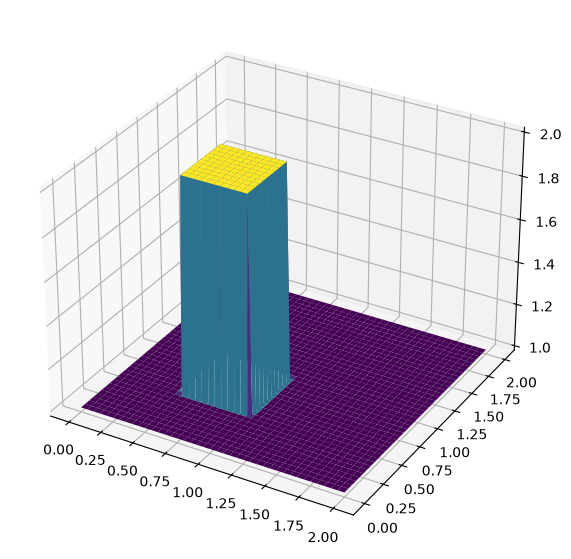

In [7]:
# importing a 3D viewer library
from mpl_toolkits.mplot3d import Axes3D

# importing neccesary libraries
import numpy as np
import matplotlib.pyplot as plt


# initializing parameters
nx = 81 # number of x spatial grid points
ny = 81 # number of y spatial grid points
nt = 100 # number of time steps
c = 1
dx = 2 / (nx - 1) # x spatial grid size
dy = 2 / (ny - 1) # y spatial grid size
sigma = 0.2 # CFL number
dt = sigma * dx # time step size


# initializing the 2D grid for plotting
x  = np.linspace(0, 2, nx)
y  = np.linspace(0, 2, ny)

# creating the permanent and temporary 2D array
u = np.ones((ny, nx)) # permanent array
un = np.ones((ny, nx)) # temporary array


# setting the initial conditions
u[int(0.5 / dy):int(1 / dy + 1), int(0.5 / dx):int(1 / dx + 1)] = 2 # set the initial condition to 2 in a square region

# plotting the initial conditions
fig = plt.figure(figsize=(11, 7), dpi=100)
ax = fig.add_subplot(projection='3d')
X, Y = np.meshgrid(x, y)
surf = ax.plot_surface(X, Y, u[:], cmap='viridis')

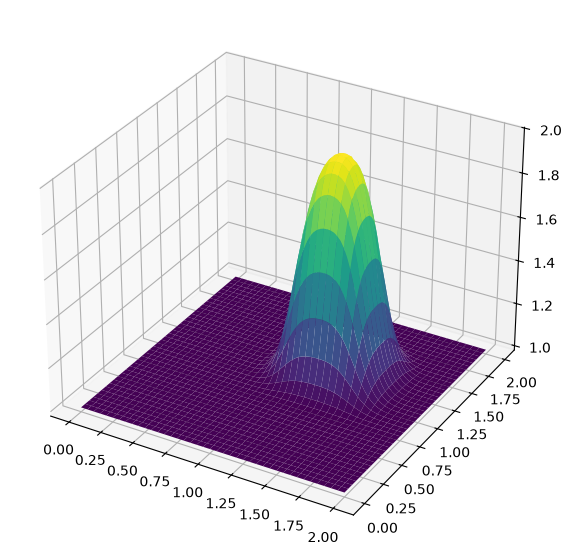

In [8]:
# Solving for successive time steps

# initializing the 2D array and setting boundary conditions
u = np.ones((ny, nx)) # permanent array

u[int(0.5 / dy):int(1 / dy + 1), int(0.5 / dx):int(1 / dx + 1)] = 2 # set the initial condition to 2 in a square region 

# the iteration
for n in range(nt + 1): # loop over time steps
    un = u.copy() # copy the current state to the temporary array
    row, column = u.shape # get the shape of the array
    for j in range(1, row): # loop over y spatial grid points
        for i in range(1, column): # loop over x spatial grid points
            u[j, i] = (un[j, i] - 
                       c * dt / dx * (un[j, i] - un[j, i - 1]) - 
                       c * dt / dy * (un[j, i] - un[j - 1, i])) # update the state using the finite difference scheme

            # setting the boundary conditions
            u[0, :] = 1 # set the boundary condition at y=0
            u[-1, :] = 1 # set the boundary condition at y=2
            u[:, 0] = 1 # set the boundary condition at x=0
            u[:, -1] = 1 # set the boundary condition at x=2


# plotting the final state
fig = plt.figure(figsize=(11, 7), dpi=100 )
ax = fig.add_subplot(projection='3d')
X, Y = np.meshgrid(x, y)
surf = ax.plot_surface(X, Y, u[:], cmap='viridis')

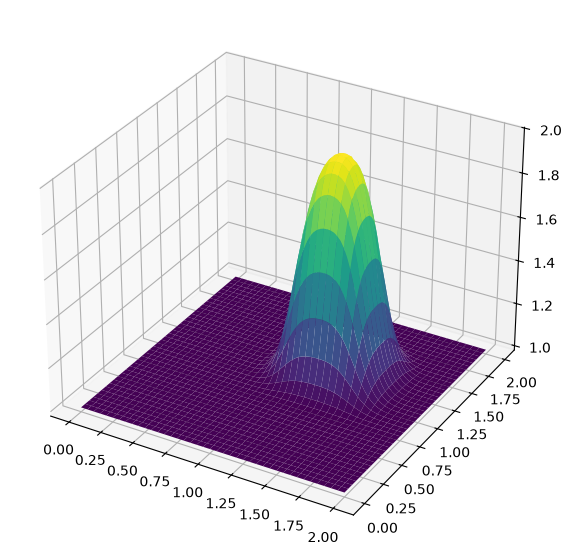

In [9]:
# improving the runtime of the code by using vectorization instead of nested loops

u = np.ones((nx, ny)) # permanent array
u[int(0.5 / dy):int(1 / dy + 1), int(0.5 / dx):int(1 / dx + 1)] = 2 # set the initial condition to 2 in a square region

# iterating over time steps
for n in range(nt + 1): # loop over time steps
    un = u.copy() # copy the current state to the temporary array
    u[1:, 1:] = (un[1:, 1:] - 
                 c * dt / dx * (un[1:, 1:] - un[1:, :-1]) - 
                 c * dt / dy * (un[1:, 1:] - un[:-1, 1:])) # update the state using the finite difference scheme

    # setting the boundary conditions
    u[0, :] = 1 # set the boundary condition at y=0
    u[-1, :] = 1 # set the boundary condition at y=2
    u[:, 0] = 1 # set the boundary condition at x=0
    u[:, -1] = 1 # set the boundary condition at x=2

# plotting the final state
fig = plt.figure(figsize=(11, 7), dpi=100 )
ax = fig.add_subplot(projection='3d')
X, Y = np.meshgrid(x, y)
surf = ax.plot_surface(X, Y, u[:], cmap='viridis')